## **Supervised Model III – XGBoost (Improved)**

Key changes from XGBoost_improved2:

1. build_unsupervised_scores_latent now does everything in one function. It ***fits SVD on normal-user interactions only***  to get a 50-dimensional latent space, then runs IF, LOF, and Mahalanobis in that latent space rather than on the handcrafted features. The SVD latent vectors preserve which items each user interacted with and how their rating patterns relate to other users — exactly the kind of structure where anomalous users should form detectable outliers. The function also returns the SVD reconstruction error and latent centroid distance as two additional features (so 5 unsupervised features total instead of 3).

*(results not submitted to codabench, on account of terrible diagnostics on unsupervised models – view graph below)*

IF (0.256), Mahalanobis (0.256), and latent dist (0.173) are all anti-correlated — they score anomalous users as more normal than actual normal users. This means the anomalies in your dataset aren't outliers in the latent space. They're the opposite: they sit closer to the centre than real users do. Real users have idiosyncratic tastes that push them away from the centroid, while the generated anomalies appear to produce "generic" or "consensus-like" patterns — rating popular items with average scores, making them hyper-normal in position space.

That's why distance-based methods (IF, Mahalanobis, latent dist) all invert. *They're designed to flag points far from the crowd, but your anomalies are hiding inside the crowd.*

The diagnostics revealed something important about how the anomalies are generated: they're "hyper-normal" — they sit closer to the population centre than real users do. Real users have quirky tastes that make them outliers, while the generated anomalies produce generic, consensus-like rating patterns. That's why every distance-based score in latent space inverted (AUC < 0.5) — they were perfectly detecting that anomalies are unusually close to average.

But SVD reconstruction MSE (0.765) still worked. That's because it measures something different: the anomalies are in the right neighbourhood but their actual rating values are inconsistent with the latent factors at that position. They're posing as average users but getting the details wrong.

In [1]:
results = []

In [2]:
import matplotlib.pyplot as plt
import zipfile, warnings
import xgboost as xgb
import pandas as pd
import numpy as np
import optuna
from scipy.stats import entropy
from scipy.spatial.distance import mahalanobis
from scipy.sparse import csr_matrix
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import TruncatedSVD, NMF

warnings.filterwarnings('ignore')

TOTAL_ITEMS = 1000
RATING_RANGE = range(6)
N_SVD_COMPONENTS = 50

/Users/tori/Documents/OFFICES/SCHOOL/Y3S2/Machine_Learning_421_SMU/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### **Data Loading**

In [3]:
# ── I/O helpers ──────────────────────────────────────────────────────

def load_npz(path: str) -> tuple[pd.DataFrame, pd.DataFrame | None]:
    data = np.load(path)
    XX = pd.DataFrame(data["X"], columns=["user", "item", "rating"])
    yy = None
    if "y" in data:
        yy = pd.DataFrame(data["y"], columns=["user", "label"])
    return XX, yy


def combine_labeled_data(
    *npz_paths: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    all_X, all_y = [], []
    for path in npz_paths:
        data = np.load(path)
        all_X.append(pd.DataFrame(data["X"], columns=["user", "item", "rating"]))
        all_y.append(pd.DataFrame(data["y"], columns=["user", "label"]))

    XX = pd.concat(all_X, ignore_index=True)
    yy = pd.concat(all_y, ignore_index=True).drop_duplicates(subset="user", keep="first")

    n_anom = int(yy["label"].sum())
    print(f"Combined {len(npz_paths)} files")
    print(f"{yy.shape[0]} users ({n_anom} anomalous, {yy.shape[0] - n_anom} normal), {XX.shape[0]} interactions")
    return XX, yy

In [4]:
# ── Sparse matrix builder ────────────────────────────────────────────

def build_user_item_matrix(XX: pd.DataFrame, user_ids: np.ndarray):
    """Build a sparse user×item rating matrix.
    
    Returns:
        mat: sparse CSR matrix (n_users × TOTAL_ITEMS)
        uid_to_row: dict mapping user_id → row index
    """
    uid_to_row = {uid: i for i, uid in enumerate(user_ids)}

    # Vectorised — avoid iterrows on 400k+ rows
    mask = XX["user"].isin(uid_to_row)
    sub = XX.loc[mask]
    rows = sub["user"].map(uid_to_row).values
    cols = sub["item"].values.astype(int)
    vals = sub["rating"].values.astype(float)

    mat = csr_matrix((vals, (rows, cols)), shape=(len(user_ids), TOTAL_ITEMS))
    return mat, uid_to_row

In [5]:
# ── Original hand-crafted features (kept from your notebook) ────────

def compute_item_stats(XX_train: pd.DataFrame) -> dict:
    item_avg = XX_train.groupby("item")["rating"].mean().rename("item_avg_rating")
    item_pop = XX_train.groupby("item")["user"].count().rename("item_popularity")
    return {"item_avg_rating": item_avg, "item_popularity": item_pop}


def build_handcrafted_features(
    XX: pd.DataFrame,
    item_stats: dict,
    total_items: int = TOTAL_ITEMS,
) -> pd.DataFrame:
    """Original 24 features — unchanged from your notebook."""
    item_avg = item_stats["item_avg_rating"]
    item_pop = item_stats["item_popularity"]

    stats = XX.groupby("user")["rating"].agg(
        rating_mean="mean", rating_std="std", rating_median="median",
        rating_min="min", rating_max="max", rating_count="count",
    )
    stats["rating_std"] = stats["rating_std"].fillna(0)
    stats["rating_range"] = stats["rating_max"] - stats["rating_min"]

    rdist = XX.groupby(["user", "rating"]).size().unstack(fill_value=0)
    rdist = rdist.reindex(columns=RATING_RANGE, fill_value=0)
    rprops = rdist.div(rdist.sum(axis=1), axis=0)
    rprops.columns = [f"prop_rating_{i}" for i in RATING_RANGE]
    stats["rating_entropy"] = rprops.apply(
        lambda row: entropy(row.values[row.values > 0]), axis=1
    )
    stats = stats.join(rprops)
    stats["prop_extreme"] = rprops["prop_rating_0"] + rprops["prop_rating_5"]

    stats["unique_items_rated"] = XX.groupby("user")["item"].nunique()
    stats["item_coverage_ratio"] = stats["unique_items_rated"] / total_items

    XX_pop = XX.merge(item_pop, left_on="item", right_index=True, how="left")
    XX_pop["item_popularity"] = XX_pop["item_popularity"].fillna(0)
    pop_f = XX_pop.groupby("user")["item_popularity"].agg(
        avg_item_popularity="mean", std_item_popularity="std",
    )
    pop_f["std_item_popularity"] = pop_f["std_item_popularity"].fillna(0)
    stats = stats.join(pop_f)

    XX_dev = XX.merge(item_avg, left_on="item", right_index=True, how="left")
    global_train_mean = item_avg.mean()
    XX_dev["item_avg_rating"] = XX_dev["item_avg_rating"].fillna(global_train_mean)
    XX_dev["deviation"] = XX_dev["rating"] - XX_dev["item_avg_rating"]
    dev_f = XX_dev.groupby("user")["deviation"].agg(
        mean_deviation="mean", std_deviation="std",
        abs_mean_deviation=lambda x: np.mean(np.abs(x)),
    )
    dev_f["std_deviation"] = dev_f["std_deviation"].fillna(0)
    stats = stats.join(dev_f)

    iqf = XX_dev.groupby("user")["item_avg_rating"].agg(
        avg_item_avg_rating="mean", std_item_avg_rating="std",
    )
    iqf["std_item_avg_rating"] = iqf["std_item_avg_rating"].fillna(0)
    stats = stats.join(iqf)

    return stats.reset_index()

In [6]:
# ── NEW: Structural features ─────────────────────────────────────────

def build_structural_features(XX: pd.DataFrame) -> pd.DataFrame:
    """Features that capture the *shape* of a user's behaviour,
    not just summary statistics.  These generalise across anomaly types."""

    feats = pd.DataFrame({"user": XX["user"].unique()})

    # ── Global rating distribution (for KL divergence) ────────────────
    global_dist = XX["rating"].value_counts(normalize=True).reindex(RATING_RANGE, fill_value=0).values
    global_dist = np.clip(global_dist, 1e-10, None)  # avoid log(0)

    def user_kl(group):
        user_dist = group["rating"].value_counts(normalize=True).reindex(RATING_RANGE, fill_value=0).values
        user_dist = np.clip(user_dist, 1e-10, None)
        return entropy(user_dist, global_dist)

    kl_df = XX.groupby("user").apply(user_kl).rename("kl_div_from_global")
    feats = feats.merge(kl_df, on="user", how="left")

    # ── Gini coefficient of item selection ────────────────────────────
    def gini_coeff(group):
        counts = group["item"].value_counts().values.astype(float)
        if len(counts) <= 1:
            return 0.0
        counts = np.sort(counts)
        n = len(counts)
        index = np.arange(1, n + 1)
        return (2.0 * np.sum(index * counts) / (n * np.sum(counts))) - (n + 1.0) / n

    gini_df = XX.groupby("user").apply(gini_coeff).rename("item_gini")
    feats = feats.merge(gini_df, on="user", how="left")

    # ── Rating "flatness" — how uniform is the rating vector? ────────
    def rating_flatness(group):
        ratings = group["rating"].values
        if len(ratings) <= 1:
            return 0.0
        # proportion of ratings equal to the mode
        vals, counts = np.unique(ratings, return_counts=True)
        return counts.max() / len(ratings)

    flat_df = XX.groupby("user").apply(rating_flatness).rename("rating_mode_frac")
    feats = feats.merge(flat_df, on="user", how="left")

    # ── Rating skewness & kurtosis ───────────────────────────────────
    skew_df = XX.groupby("user")["rating"].skew().rename("rating_skew").fillna(0)
    kurt_df = XX.groupby("user")["rating"].apply(
        lambda x: x.kurtosis() if len(x) >= 4 else 0.0
    ).rename("rating_kurtosis")
    feats = feats.merge(skew_df, on="user", how="left")
    feats = feats.merge(kurt_df, on="user", how="left")

    # ── Item overlap with popular items ──────────────────────────────
    top_items = set(XX["item"].value_counts().head(100).index)
    def top_item_frac(group):
        user_items = set(group["item"].values)
        return len(user_items & top_items) / max(len(user_items), 1)

    top_df = XX.groupby("user").apply(top_item_frac).rename("frac_top100_items")
    feats = feats.merge(top_df, on="user", how="left")

    # ── Ratings-per-item ratio (detects multi-rating anomalies) ─────
    rpi = XX.groupby("user").apply(
        lambda g: len(g) / g["item"].nunique()
    ).rename("ratings_per_item")
    feats = feats.merge(rpi, on="user", how="left")

    return feats

In [7]:
# ── SVD features are now computed inside build_unsupervised_scores_latent ─
# (cell above merges SVD reconstruction + latent-space IF/LOF/Mahalanobis
#  into a single function to avoid fitting SVD twice)
pass


In [8]:
# ── Unsupervised anomaly scores (on SVD LATENT space, not handcrafted) ─
#
# KEY CHANGE: IF/LOF/Mahalanobis now operate on the 50-dim SVD latent
# vectors instead of the 35 handcrafted features.  The SVD space preserves
# *which items* a user rated and *how*, so geometric outlier detection
# actually has structure to work with.

def build_unsupervised_scores_latent(
    XX_ref: pd.DataFrame,
    XX_target: pd.DataFrame,
    target_users: np.ndarray,
    ref_normal_users: np.ndarray,
    n_components: int = N_SVD_COMPONENTS,
) -> tuple[np.ndarray, TruncatedSVD]:
    """Fit SVD on normal-user interactions, then run IF/LOF/Mahalanobis
    in the latent space.  Returns (scores_array, svd_model).

    scores_array shape: (n_target_users, 5)
      [iso_forest, lof, mahalanobis, svd_recon_mse, svd_latent_dist]
    """
    # ── Fit SVD on normal users only ─────────────────────────────────
    XX_normal = XX_ref[XX_ref["user"].isin(ref_normal_users)]
    normal_uids = XX_normal["user"].unique()
    normal_mat, _ = build_user_item_matrix(XX_normal, normal_uids)

    n_comp = min(n_components, min(normal_mat.shape) - 1)
    svd = TruncatedSVD(n_components=n_comp, random_state=42)
    svd.fit(normal_mat)

    # Normal users in latent space (reference for IF/LOF/Mahalanobis)
    Z_normal = svd.transform(normal_mat)
    centroid = Z_normal.mean(axis=0)

    # Target users in latent space
    target_mat, _ = build_user_item_matrix(XX_target, target_users)
    Z_target = svd.transform(target_mat)

    # ── SVD reconstruction error (on rated items only) ──────────────
    reconstructed = Z_target @ svd.components_
    target_dense = target_mat.toarray()
    mask = (target_dense != 0).astype(float)
    diff = (target_dense - reconstructed) * mask
    n_rated = np.maximum(np.sum(mask, axis=1), 1)
    recon_mse = np.sum(diff ** 2, axis=1) / n_rated

    # ── Latent distance from normal centroid ────────────────────────
    latent_dist = np.linalg.norm(Z_target - centroid, axis=1)

    # ── Isolation Forest in latent space ────────────────────────────
    iso = IsolationForest(
        n_estimators=500, contamination="auto", random_state=42, n_jobs=-1
    )
    iso.fit(Z_normal)
    iso_scores = -iso.score_samples(Z_target)

    # ── LOF in latent space ─────────────────────────────────────────
    n_neighbors = min(20, len(Z_normal) - 1)
    lof = LocalOutlierFactor(
        n_neighbors=n_neighbors, contamination="auto", novelty=True, n_jobs=-1
    )
    lof.fit(Z_normal)
    lof_scores = -lof.score_samples(Z_target)

    # ── Mahalanobis in latent space ─────────────────────────────────
    try:
        cov = np.cov(Z_normal, rowvar=False)
        cov += np.eye(cov.shape[0]) * 1e-6
        cov_inv = np.linalg.inv(cov)
        maha_scores = np.array([
            mahalanobis(z, centroid, cov_inv) for z in Z_target
        ])
    except Exception:
        maha_scores = latent_dist  # fallback

    scores = np.column_stack([
        iso_scores, lof_scores, maha_scores, recon_mse, latent_dist
    ])
    return scores, svd


UNSUP_COLS = [
    "iso_forest_latent", "lof_latent", "mahalanobis_latent",
    "svd_recon_mse", "svd_latent_dist",
]


In [9]:
# ── Combined feature pipeline ────────────────────────────────────────

def build_all_features(
    XX: pd.DataFrame,
    item_stats: dict,
) -> pd.DataFrame:
    """Merge handcrafted + structural features for a set of users.
    SVD and unsupervised scores are added separately (they need ref/target split).
    """
    hc = build_handcrafted_features(XX, item_stats)
    st = build_structural_features(XX)
    merged = hc.merge(st, on="user", how="left")
    return merged

In [ ]:
# ── Fold feature builder (latent-space unsupervised) ─────────────────

def make_fold_features(XX_raw, yy_raw, train_users, val_users):
    """Build all features for one CV fold.
    Unsupervised models now operate in SVD latent space (not handcrafted features).
    """
    XX_tr  = XX_raw[XX_raw["user"].isin(train_users)].copy()
    XX_val = XX_raw[XX_raw["user"].isin(val_users)].copy()
    yy_tr  = yy_raw[yy_raw["user"].isin(train_users)].copy()
    yy_val = yy_raw[yy_raw["user"].isin(val_users)].copy()

    normal_train_users = yy_tr[yy_tr["label"] == 0]["user"].values
    item_stats_tr = compute_item_stats(XX_tr)

    # Handcrafted + structural features
    feats_tr  = build_all_features(XX_tr, item_stats_tr).merge(yy_tr, on="user")
    feats_val = build_all_features(XX_val, item_stats_tr).merge(yy_val, on="user")

    # Unsupervised scores in SVD latent space (fitted on normal train users)
    unsup_tr_scores, svd_model = build_unsupervised_scores_latent(
        XX_ref=XX_tr, XX_target=XX_tr,
        target_users=feats_tr["user"].values,
        ref_normal_users=normal_train_users,
    )
    unsup_val_scores, _ = build_unsupervised_scores_latent(
        XX_ref=XX_tr, XX_target=XX_val,
        target_users=feats_val["user"].values,
        ref_normal_users=normal_train_users,
    )

    # Add unsupervised scores as columns
    for j, col in enumerate(UNSUP_COLS):
        feats_tr[col]  = unsup_tr_scores[:, j]
        feats_val[col] = unsup_val_scores[:, j]

    feature_cols = [c for c in feats_tr.columns if c not in ["user", "label"]]
    feats_val = feats_val[["user", "label"] + feature_cols]

    scaler_fold = RobustScaler()
    X_tr_s  = scaler_fold.fit_transform(feats_tr[feature_cols].values)
    X_val_s = scaler_fold.transform(feats_val[feature_cols].values)

    y_tr  = feats_tr["label"].values
    y_val = feats_val["label"].values

    return (
        X_tr_s, y_tr, X_val_s, y_val,
        item_stats_tr, feature_cols, scaler_fold, svd_model,
        normal_train_users,
    )


In [11]:
# ── Evaluation helper ────────────────────────────────────────────────

def codabench_metrics(test_labels, scores, model_name, verbose=False):
    test_labels = np.asarray(test_labels).astype(int)
    scores = np.asarray(scores).astype(float)
    preds = (scores >= 0.5).astype(int)
    metrics = {
        "model": model_name,
        "AUC": roc_auc_score(test_labels, scores),
        "Precision": precision_score(test_labels, preds, zero_division=0),
        "Recall": recall_score(test_labels, preds, zero_division=0),
        "F1": f1_score(test_labels, preds, zero_division=0),
        "threshold": 0.5,
    }
    if verbose:
        print(f"{model_name} (Codabench t=0.5)")
        for k in ["AUC", "Precision", "Recall", "F1"]:
            print(f"# {k+':':12s} {metrics[k]:.4f}")
    return metrics

In [12]:
# Phase 3 data loading
XX_all, yy_all = combine_labeled_data(
    "data/training_batch_with_labels.npz",
    "data/first_batch_with_labels.npz",
    "data/second_batch_with_labels.npz",
)

Combined 3 files
3060 users (260 anomalous, 2800 normal), 479433 interactions


In [13]:
# Build full feature set for Optuna
item_stats_full = compute_item_stats(XX_all)
full_train_df = build_all_features(XX_all, item_stats_full).merge(yy_all, on="user")

normal_users_all = yy_all[yy_all["label"] == 0]["user"].values

# Unsupervised scores in SVD latent space
unsup_all_scores, svd_full_model = build_unsupervised_scores_latent(
    XX_ref=XX_all, XX_target=XX_all,
    target_users=full_train_df["user"].values,
    ref_normal_users=normal_users_all,
)
for j, col in enumerate(UNSUP_COLS):
    full_train_df[col] = unsup_all_scores[:, j]

feature_cols = [c for c in full_train_df.columns if c not in ["user", "label"]]

X_trainval = full_train_df[feature_cols].values
y_trainval = full_train_df["label"].values

scaler = RobustScaler()
X_trainval_s = scaler.fit_transform(X_trainval)
feature_cols_all = feature_cols  # unsup cols already included

print(f"Training users: {len(y_trainval)}")
print(f"Features:       {len(feature_cols_all)}")
print(f"Feature names:  {feature_cols_all}")


Training users: 3060
Features:       36
Feature names:  ['rating_mean', 'rating_std', 'rating_median', 'rating_min', 'rating_max', 'rating_count', 'rating_range', 'rating_entropy', 'prop_rating_0', 'prop_rating_1', 'prop_rating_2', 'prop_rating_3', 'prop_rating_4', 'prop_rating_5', 'prop_extreme', 'unique_items_rated', 'item_coverage_ratio', 'avg_item_popularity', 'std_item_popularity', 'mean_deviation', 'std_deviation', 'abs_mean_deviation', 'avg_item_avg_rating', 'std_item_avg_rating', 'kl_div_from_global', 'item_gini', 'rating_mode_frac', 'rating_skew', 'rating_kurtosis', 'frac_top100_items', 'ratings_per_item', 'iso_forest_latent', 'lof_latent', 'mahalanobis_latent', 'svd_recon_mse', 'svd_latent_dist']


#### **Optuna Hyperparameter Search (F1-optimised)**

In [14]:
from sklearn.metrics import fbeta_score

spw_global = np.sum(y_trainval == 0) / np.sum(y_trainval == 1)
OPTUNA_BETA = 1.5  # >1 biases toward recall; try 1.5 or 2.0

def objective(trial):
    grow_policy = trial.suggest_categorical("grow_policy", ["depthwise", "lossguide"])

    params = dict(
        n_estimators      = trial.suggest_int("n_estimators", 100, 4000),
        learning_rate     = trial.suggest_float("learning_rate", 0.001, 0.15, log=True),
        subsample         = trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree  = trial.suggest_float("colsample_bytree", 0.4, 1.0),
        colsample_bylevel = trial.suggest_float("colsample_bylevel", 0.4, 1.0),
        colsample_bynode  = trial.suggest_float("colsample_bynode", 0.4, 1.0),
        min_child_weight  = trial.suggest_int("min_child_weight", 1, 10),
        gamma             = trial.suggest_float("gamma", 0.0, 2.0),
        reg_alpha         = trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        reg_lambda        = trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        max_delta_step    = trial.suggest_int("max_delta_step", 0, 10),
        scale_pos_weight  = trial.suggest_float("scale_pos_weight", spw_global * 0.5, spw_global * 3.0),
        grow_policy       = grow_policy,
    )

    if grow_policy == "lossguide":
        params["max_leaves"] = trial.suggest_int("max_leaves", 16, 512)
    else:
        params["max_depth"] = trial.suggest_int("max_depth", 3, 12)

    # 5-fold CV, optimise for F-beta (recall-biased)
    # NOTE: minor leakage in unsup scores for speed; proper CV below.
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=trial.number)
    fold_fbetas = []
    fold_f1s = []
    fold_aucs = []

    for tr_i, val_i in cv.split(X_trainval_s, y_trainval):
        m = xgb.XGBClassifier(
            **params,
            eval_metric="aucpr",
            early_stopping_rounds=50,
            random_state=42,
            n_jobs=-1,
            tree_method="hist",
        )
        m.fit(
            X_trainval_s[tr_i], y_trainval[tr_i],
            eval_set=[(X_trainval_s[val_i], y_trainval[val_i])],
            verbose=False,
        )
        proba = m.predict_proba(X_trainval_s[val_i])[:, 1]
        preds = (proba >= 0.5).astype(int)
        fold_fbetas.append(fbeta_score(y_trainval[val_i], preds, beta=OPTUNA_BETA, zero_division=0))
        fold_f1s.append(f1_score(y_trainval[val_i], preds, zero_division=0))
        fold_aucs.append(roc_auc_score(y_trainval[val_i], proba))

    trial.set_user_attr("mean_auc", np.mean(fold_aucs))
    trial.set_user_attr("mean_f1", np.mean(fold_f1s))
    return np.mean(fold_fbetas)


In [15]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=300, show_progress_bar=True)

best_params = study.best_params
print(f"Best CV F-beta({OPTUNA_BETA}): {study.best_value:.4f}")
print(f"Best CV F1:         {study.best_trial.user_attrs['mean_f1']:.4f}")
print(f"Best CV AUC:        {study.best_trial.user_attrs['mean_auc']:.4f}")
print("Best params:", best_params)


[I 2026-03-29 17:30:15,819] A new study created in memory with name: no-name-bd3b3e13-76f5-4c31-bc8c-bf6ee6acb6c6
Best trial: 0. Best value: 0.33156:   0%|          | 1/300 [00:04<24:03,  4.83s/it]

[I 2026-03-29 17:30:20,645] Trial 0 finished with value: 0.33156045103887444 and parameters: {'grow_policy': 'lossguide', 'n_estimators': 627, 'learning_rate': 0.0029678020705187756, 'subsample': 0.6300151941906338, 'colsample_bytree': 0.8718934512355603, 'colsample_bylevel': 0.49407296771616116, 'colsample_bynode': 0.6467766311300578, 'min_child_weight': 8, 'gamma': 0.15799857686229601, 'reg_alpha': 1.5061242014792644, 'reg_lambda': 0.004422618172751549, 'max_delta_step': 1, 'scale_pos_weight': 18.447845200498858, 'max_leaves': 284}. Best is trial 0 with value: 0.33156045103887444.


Best trial: 1. Best value: 0.546745:   1%|          | 2/300 [00:08<20:28,  4.12s/it]

[I 2026-03-29 17:30:24,276] Trial 1 finished with value: 0.5467446681848949 and parameters: {'grow_policy': 'depthwise', 'n_estimators': 3396, 'learning_rate': 0.009315523232198869, 'subsample': 0.9449848144614288, 'colsample_bytree': 0.7623014925296592, 'colsample_bylevel': 0.5896717096638577, 'colsample_bynode': 0.7654910672006384, 'min_child_weight': 6, 'gamma': 1.551401454629248, 'reg_alpha': 0.0006568527393637497, 'reg_lambda': 5.8783952769408305, 'max_delta_step': 8, 'scale_pos_weight': 5.57095247790149, 'max_depth': 8}. Best is trial 1 with value: 0.5467446681848949.


Best trial: 2. Best value: 0.797741:   1%|          | 3/300 [00:10<16:41,  3.37s/it]

...

[I 2026-03-29 17:46:21,489] Trial 297 finished with value: 0.7982903853989839 and parameters: {'grow_policy': 'lossguide', 'n_estimators': 2222, 'learning_rate': 0.07687372434637726, 'subsample': 0.9997702386063564, 'colsample_bytree': 0.44721404065008574, 'colsample_bylevel': 0.4666113233417682, 'colsample_bynode': 0.8537957649360404, 'min_child_weight': 1, 'gamma': 0.2008473810883609, 'reg_alpha': 0.013394703830862541, 'reg_lambda': 0.7379170344346803, 'max_delta_step': 10, 'scale_pos_weight': 26.460283815055256, 'max_leaves': 433}. Best is trial 251 with value: 0.8244506033746731.


Best trial: 251. Best value: 0.824451: 100%|█████████▉| 299/300 [16:08<00:03,  3.32s/it]

[I 2026-03-29 17:46:24,434] Trial 298 finished with value: 0.817321913955914 and parameters: {'grow_policy': 'lossguide', 'n_estimators': 544, 'learning_rate': 0.14959744833210317, 'subsample': 0.9795939574633518, 'colsample_bytree': 0.49231145366025497, 'colsample_bylevel': 0.5203749319743775, 'colsample_bynode': 0.8302045044960508, 'min_child_weight': 1, 'gamma': 0.09456665787827767, 'reg_alpha': 0.007945379235749339, 'reg_lambda': 2.3173057632809186, 'max_delta_step': 5, 'scale_pos_weight': 25.958985687080666, 'max_leaves': 402}. Best is trial 251 with value: 0.8244506033746731.


Best trial: 251. Best value: 0.824451: 100%|██████████| 300/300 [16:11<00:00,  3.24s/it]

[I 2026-03-29 17:46:27,001] Trial 299 finished with value: 0.7907751213914893 and parameters: {'grow_policy': 'lossguide', 'n_estimators': 520, 'learning_rate': 0.1401219893939705, 'subsample': 0.9547168168478898, 'colsample_bytree': 0.5149557579053139, 'colsample_bylevel': 0.4916285748107296, 'colsample_bynode': 0.8244249532068989, 'min_child_weight': 2, 'gamma': 0.07652703242207766, 'reg_alpha': 0.008068604038422047, 'reg_lambda': 1.3299195592259467, 'max_delta_step': 5, 'scale_pos_weight': 26.816026726272128, 'max_leaves': 393}. Best is trial 251 with value: 0.8244506033746731.
Best CV F-beta(1.5): 0.8245
Best CV F1:         0.8305
Best CV AUC:        0.9824
Best params: {'grow_policy': 'lossguide', 'n_estimators': 493, 'learning_rate': 0.14786831016497992, 'subsample': 0.9866855713453772, 'colsample_bytree': 0.9657393224794569, 'colsample_bylevel': 0.5047834590531818, 'colsample_bynode': 0.8738172061359036, 'min_child_weight': 1, 'gamma': 0.17429885964769984, 'reg_alpha': 0.0066130

#### **Cross-Validation (5-fold)**

In [16]:
N_FOLDS = 5
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_scores = np.zeros(len(y_trainval))
fold_aucs = []
fold_f1s  = []
fold_artifacts = []

for fold, (tr_idx, va_idx) in enumerate(cv.split(full_train_df[feature_cols].values, y_trainval), 1):
    train_users = full_train_df.iloc[tr_idx]["user"].values
    val_users   = full_train_df.iloc[va_idx]["user"].values

    # Build fold-specific features (normal-only unsupervised fitting)
    X_tr, y_tr, X_va, y_va, item_stats_tr, feat_cols_fold, scaler_fold, svd_fold, normal_users_fold = \
        make_fold_features(XX_all, yy_all, train_users, val_users)

    model = xgb.XGBClassifier(
        **best_params,
        eval_metric="auc",
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
    )
    model.fit(X_tr, y_tr, verbose=False)

    p_va = model.predict_proba(X_va)[:, 1]
    oof_scores[va_idx] = p_va

    fold_auc = roc_auc_score(y_va, p_va)
    fold_f1  = f1_score(y_va, (p_va >= 0.5).astype(int), zero_division=0)
    fold_aucs.append(fold_auc)
    fold_f1s.append(fold_f1)

    fold_artifacts.append({
        "model": model,
        "item_stats": item_stats_tr,
        "feature_cols": feat_cols_fold,
        "scaler": scaler_fold,
        "svd": svd_fold,
        "normal_users": normal_users_fold,
    })

    print(f"Fold {fold:02d}  AUC: {fold_auc:.4f}  F1: {fold_f1:.4f}")

print(f"\nMean fold AUC: {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")
print(f"Mean fold F1:  {np.mean(fold_f1s):.4f} ± {np.std(fold_f1s):.4f}")
print(f"OOF AUC:       {roc_auc_score(y_trainval, oof_scores):.4f}")
print(f"OOF F1:        {f1_score(y_trainval, (oof_scores >= 0.5).astype(int), zero_division=0):.4f}")


Fold 01  AUC: 0.9532  F1: 0.7429
Fold 02  AUC: 0.9721  F1: 0.7400
Fold 03  AUC: 0.9647  F1: 0.7167
Fold 04  AUC: 0.9655  F1: 0.7925
Fold 05  AUC: 0.9693  F1: 0.7544

Mean fold AUC: 0.9650 ± 0.0064
Mean fold F1:  0.7493 ± 0.0248
OOF AUC:       0.9651
OOF F1:        0.7486


#### **Results Calibration**

In [17]:
calibrator = LogisticRegression(max_iter=1000, random_state=42)
calibrator.fit(oof_scores.reshape(-1, 1), y_trainval)

oof_scores_cal = calibrator.predict_proba(oof_scores.reshape(-1, 1))[:, 1]
print(f"Calibrated OOF AUC: {roc_auc_score(y_trainval, oof_scores_cal):.4f}")
print(f"Calibrated OOF F1:  {f1_score(y_trainval, (oof_scores_cal >= 0.5).astype(int), zero_division=0):.4f}")

Calibrated OOF AUC: 0.9651
Calibrated OOF F1:  0.7683


In [18]:
# Threshold analysis
thresholds = np.linspace(0.01, 0.99, 500)
j_scores, f1_scores_t, prec_list, rec_list = [], [], [], []

for t in thresholds:
    preds_t = (oof_scores_cal >= t).astype(int)
    tp = np.sum((preds_t == 1) & (y_trainval == 1))
    tn = np.sum((preds_t == 0) & (y_trainval == 0))
    fp = np.sum((preds_t == 1) & (y_trainval == 0))
    fn = np.sum((preds_t == 0) & (y_trainval == 1))
    sens = tp / (tp + fn + 1e-9)
    spec = tn / (tn + fp + 1e-9)
    prec = tp / (tp + fp + 1e-9)
    f1_t = 2 * prec * sens / (prec + sens + 1e-9)
    j_scores.append(sens + spec - 1)
    f1_scores_t.append(f1_t)
    prec_list.append(prec)
    rec_list.append(sens)

best_j_idx  = np.argmax(j_scores)
best_f1_idx = np.argmax(f1_scores_t)

print(f"Optimal threshold — Youden's J : {thresholds[best_j_idx]:.3f}  "
      f"(prec={prec_list[best_j_idx]:.3f}, rec={rec_list[best_j_idx]:.3f})")
print(f"Optimal threshold — Best F1   : {thresholds[best_f1_idx]:.3f}  "
      f"(prec={prec_list[best_f1_idx]:.3f}, rec={rec_list[best_f1_idx]:.3f})")

Optimal threshold — Youden's J : 0.030  (prec=0.518, rec=0.885)
Optimal threshold — Best F1   : 0.691  (prec=0.885, rec=0.712)


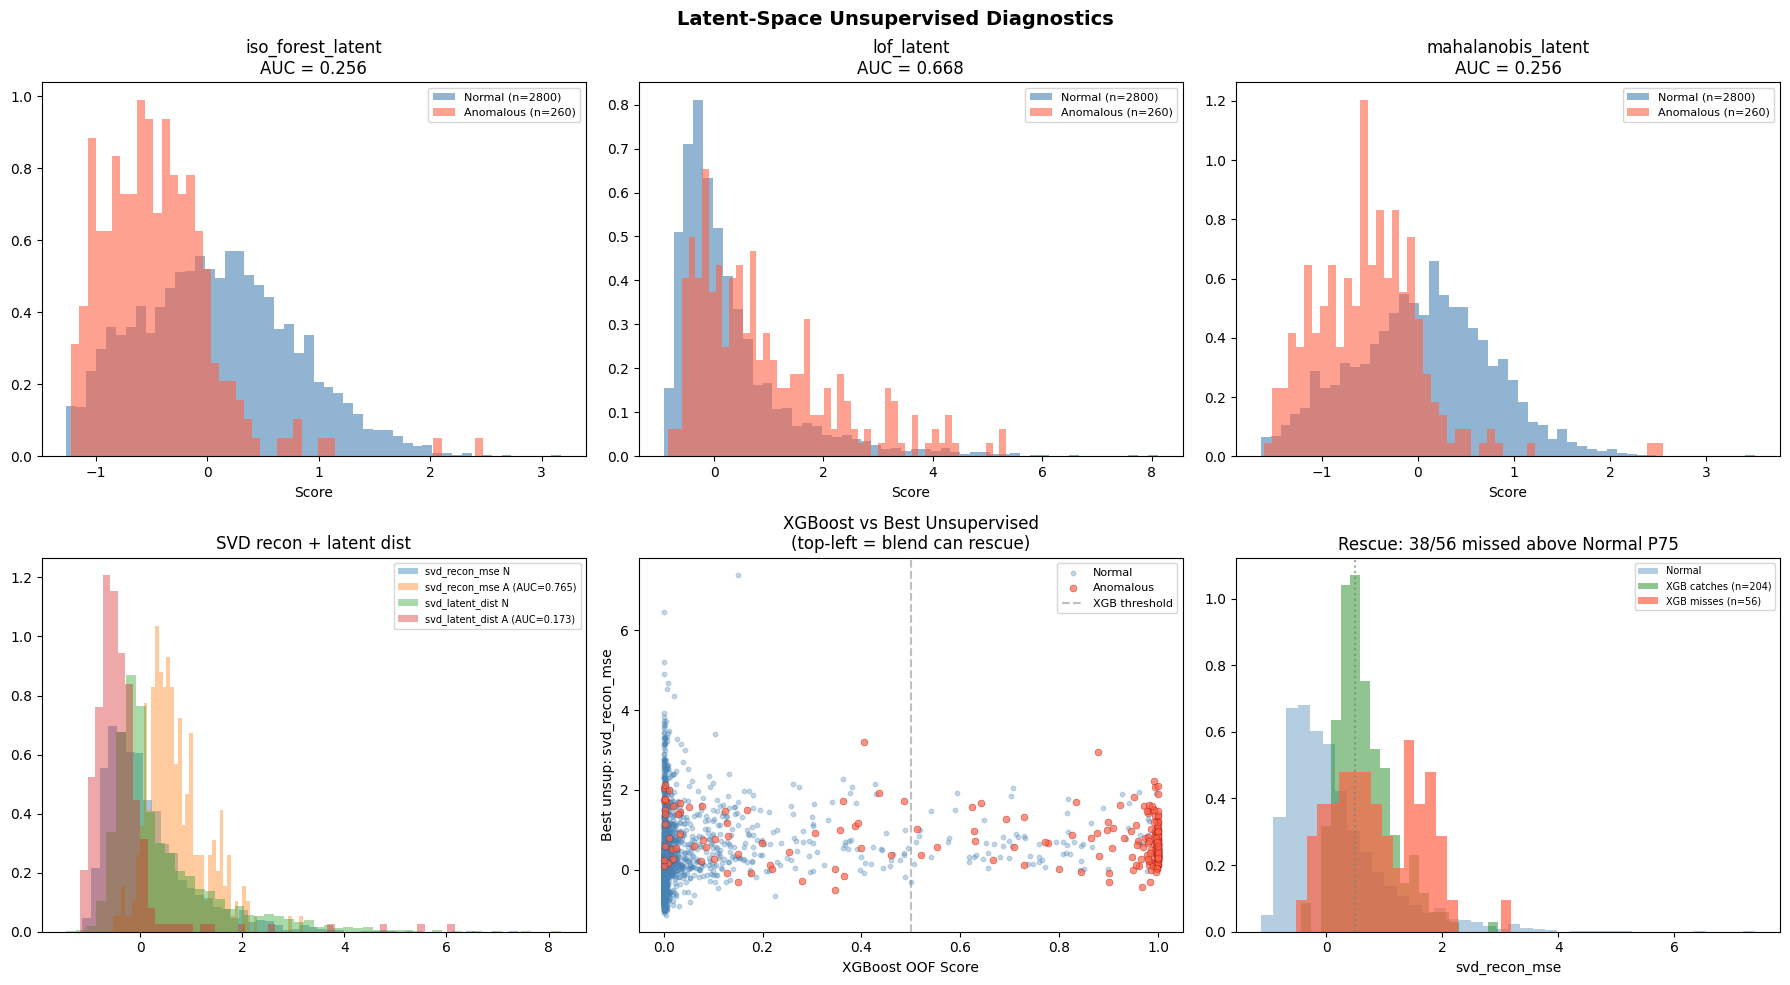


── Per-score AUCs ──────────────────────────────────────────
  iso_forest_latent              AUC = 0.256
  lof_latent                     AUC = 0.668
  mahalanobis_latent             AUC = 0.256
  svd_recon_mse                  AUC = 0.765
  svd_latent_dist                AUC = 0.173
  combined (avg)                 AUC = 0.384

XGBoost OOF AUC: 0.965
Missed by XGB:   56/260
  rescuable:     38/56

→ Weak signal. Try BLEND_ALPHA = 0.10–0.15 or disable.


In [19]:
# ── Unsupervised Score Diagnostics (Latent-Space Version) ────────────

from sklearn.metrics import roc_auc_score

# Find unsupervised columns in the feature matrix
unsup_idxs = [feature_cols_all.index(c) for c in UNSUP_COLS]
unsup_matrix = X_trainval_s[:, unsup_idxs]

labels_bool = y_trainval.astype(bool)
normal_mask = ~labels_bool
anom_mask   = labels_bool

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Latent-Space Unsupervised Diagnostics", fontsize=14, fontweight="bold")

# ── Row 1: Individual score distributions ────────────────────────────
for i, (ax, name) in enumerate(zip(axes[0], UNSUP_COLS[:3])):
    vals_n = unsup_matrix[normal_mask, i]
    vals_a = unsup_matrix[anom_mask, i]
    ax.hist(vals_n, bins=50, alpha=0.6, label=f"Normal (n={normal_mask.sum()})", density=True, color="steelblue")
    ax.hist(vals_a, bins=50, alpha=0.6, label=f"Anomalous (n={anom_mask.sum()})", density=True, color="tomato")
    auc_i = roc_auc_score(y_trainval, unsup_matrix[:, i])
    ax.set_title(f"{name}\nAUC = {auc_i:.3f}")
    ax.legend(fontsize=8)
    ax.set_xlabel("Score")

# ── Row 2, Left: SVD recon MSE + latent dist ────────────────────────
ax = axes[1][0]
for i, name in enumerate(UNSUP_COLS[3:], start=3):
    vals_n = unsup_matrix[normal_mask, i]
    vals_a = unsup_matrix[anom_mask, i]
    auc_i = roc_auc_score(y_trainval, unsup_matrix[:, i])
    ax.hist(vals_n, bins=50, alpha=0.4, density=True, label=f"{name} N")
    ax.hist(vals_a, bins=50, alpha=0.4, density=True, label=f"{name} A (AUC={auc_i:.3f})")
ax.set_title("SVD recon + latent dist")
ax.legend(fontsize=7)

# ── Row 2, Middle: XGBoost vs best unsupervised scatter ─────────────
ax = axes[1][1]
# Use the single best unsupervised score
unsup_aucs = [roc_auc_score(y_trainval, unsup_matrix[:, i]) for i in range(unsup_matrix.shape[1])]
best_idx = np.argmax(unsup_aucs)
best_unsup = unsup_matrix[:, best_idx]
ax.scatter(oof_scores[normal_mask], best_unsup[normal_mask],
           alpha=0.3, s=10, c="steelblue", label="Normal")
ax.scatter(oof_scores[anom_mask], best_unsup[anom_mask],
           alpha=0.7, s=25, c="tomato", label="Anomalous", edgecolors="darkred", linewidths=0.3)
ax.axvline(0.5, color="gray", ls="--", alpha=0.5, label="XGB threshold")
ax.set_xlabel("XGBoost OOF Score")
ax.set_ylabel(f"Best unsup: {UNSUP_COLS[best_idx]}")
ax.set_title(f"XGBoost vs Best Unsupervised\n(top-left = blend can rescue)")
ax.legend(fontsize=8)

# ── Row 2, Right: Rescue analysis ─────────────────────────────────
ax = axes[1][2]
xgb_missed = anom_mask & (oof_scores < 0.5)
xgb_caught = anom_mask & (oof_scores >= 0.5)
n_missed = xgb_missed.sum()
n_caught = xgb_caught.sum()

if n_missed > 0:
    unsup_missed = best_unsup[xgb_missed]
    unsup_normal = best_unsup[normal_mask]
    p75 = np.percentile(unsup_normal, 75)
    rescuable = (unsup_missed > p75).sum()
    ax.hist(unsup_normal, bins=40, alpha=0.4, label=f"Normal", density=True, color="steelblue")
    ax.hist(best_unsup[xgb_caught], bins=20, alpha=0.5, label=f"XGB catches (n={n_caught})", density=True, color="forestgreen")
    ax.hist(unsup_missed, bins=20, alpha=0.7, label=f"XGB misses (n={n_missed})", density=True, color="tomato")
    ax.axvline(p75, color="gray", ls=":", alpha=0.7)
    ax.set_title(f"Rescue: {rescuable}/{n_missed} missed above Normal P75")
else:
    ax.set_title("No missed anomalies")
ax.legend(fontsize=7)
ax.set_xlabel(f"{UNSUP_COLS[best_idx]}")

plt.tight_layout()
plt.show()

# ── Summary ──────────────────────────────────────────────────────────
print("\n── Per-score AUCs ──────────────────────────────────────────")
for name, auc in zip(UNSUP_COLS, unsup_aucs):
    print(f"  {name:30s} AUC = {auc:.3f}")
combined = unsup_matrix.mean(axis=1)
auc_combined = roc_auc_score(y_trainval, combined)
print(f"  {"combined (avg)":30s} AUC = {auc_combined:.3f}")
print(f"\nXGBoost OOF AUC: {roc_auc_score(y_trainval, oof_scores):.3f}")
print(f"Missed by XGB:   {n_missed}/{anom_mask.sum()}")
if n_missed > 0:
    print(f"  rescuable:     {rescuable}/{n_missed}")
print()
if auc_combined > 0.85 and n_missed > 0 and rescuable / max(n_missed, 1) > 0.4:
    print("→ Strong signal. Try BLEND_ALPHA = 0.25–0.35")
elif auc_combined > 0.75 and n_missed > 0 and rescuable / max(n_missed, 1) > 0.2:
    print("→ Moderate signal. Try BLEND_ALPHA = 0.15–0.25")
else:
    print("→ Weak signal. Try BLEND_ALPHA = 0.10–0.15 or disable.")


#### **Model Predictions**

In [20]:
# Load test data
XX_test, _ = load_npz("data/third_batch.npz")

In [21]:
# ── Test predictions with latent-space unsupervised blending ────────
fold_test_preds = []

for fold_id, art in enumerate(fold_artifacts, 1):
    model           = art["model"]
    item_stats_fold = art["item_stats"]
    feat_cols_fold  = art["feature_cols"]
    scaler_fold     = art["scaler"]
    normal_users_fold = art["normal_users"]

    # Handcrafted + structural features
    test_df = build_all_features(XX_test, item_stats_fold)

    # Unsupervised scores in latent space
    unsup_test_scores, _ = build_unsupervised_scores_latent(
        XX_ref=XX_all, XX_target=XX_test,
        target_users=test_df["user"].values,
        ref_normal_users=normal_users_fold,
    )
    for j, col in enumerate(UNSUP_COLS):
        test_df[col] = unsup_test_scores[:, j]

    for c in feat_cols_fold:
        if c not in test_df.columns:
            test_df[c] = 0.0

    X_test_s = scaler_fold.transform(test_df[feat_cols_fold].values)
    p_test = model.predict_proba(X_test_s)[:, 1]
    fold_test_preds.append(p_test)
    print(f"Generated test predictions from fold {fold_id:02d}")

fold_test_preds = np.column_stack(fold_test_preds)
y_score_raw = fold_test_preds.mean(axis=1)

# ── Standalone unsupervised blend ─────────────────────────────────
unsup_standalone, _ = build_unsupervised_scores_latent(
    XX_ref=XX_all, XX_target=XX_test,
    target_users=build_all_features(XX_test, item_stats_full)["user"].values,
    ref_normal_users=normal_users_all,
)
unsup_combined = unsup_standalone.mean(axis=1)
unsup_norm = (unsup_combined - unsup_combined.min()) / (unsup_combined.max() - unsup_combined.min() + 1e-9)

print(f"\nXGBoost raw range:  [{y_score_raw.min():.4f}, {y_score_raw.max():.4f}]")
print(f"Unsupervised range: [{unsup_norm.min():.4f}, {unsup_norm.max():.4f}]")

# ── Blend + calibrate ────────────────────────────────────────────
BLEND_ALPHA = 0.20  # adjust based on diagnostics
y_blended = (1 - BLEND_ALPHA) * y_score_raw + BLEND_ALPHA * unsup_norm

y_score_cal = calibrator.predict_proba(y_blended.reshape(-1, 1))[:, 1]
y_score_norm = (y_score_cal - y_score_cal.min()) / (y_score_cal.max() - y_score_cal.min() + 1e-9)

print(f"\nFinal shape: {y_score_norm.shape}")
print(f"Final range: [{y_score_norm.min():.4f}, {y_score_norm.max():.4f}]")


Generated test predictions from fold 01
Generated test predictions from fold 02
Generated test predictions from fold 03
Generated test predictions from fold 04
Generated test predictions from fold 05

XGBoost raw range:  [0.0000, 0.9997]
Unsupervised range: [0.0000, 1.0000]

Final shape: (1625,)
Final range: [0.0000, 1.0000]


#### **Evaluation (local/Codabench)**

In [22]:
# Save submission
np.savez("submission.npz", predictions=y_score_norm)
with zipfile.ZipFile("submission.zip", "w", zipfile.ZIP_DEFLATED) as zf:
    zf.write("submission.npz", arcname="submission.npz")
pd.DataFrame({"predictions": y_score_norm}).to_csv("submission.csv", index=False)
print("submission.zip ready for Codabench")

submission.zip ready for Codabench


results were not submitted to codabench
